# Estimating the camera pose
In this example, we estimate the pose of the camera with respect to a rectangular shape (planar object). We first estimate the homography transformation between the camera and the object. Then, we extract the Rotation matrix and Translation vector from the estimated homography.

**Important**: The steps in this notebook are given as an example to illustrate the main steps of the method. The camera that captured the Dory images is not the same camera that captured the calibration images. The images are from an OpenCV tutorial on camera calibration.

In an actual solution, we need to use the same camera that we calibrated to take the pictures of the object.

## Setup

### Imports

In [31]:
%pip -qq install pytransform3d

import os
filename = "plot_image_grid.py"
url = "https://raw.githubusercontent.com/facebookresearch/pytorch3d/main/docs/tutorials/utils/plot_image_grid.py"
if not os.path.exists(filename):
    !wget {url}


from plot_image_grid import image_grid

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection
from cvxopt import matrix, printing
from scipy.spatial.transform import Rotation as R
from mpl_toolkits.axes_grid1 import ImageGrid
import pytransform3d.camera as pc
import pytransform3d.transformations as pt
import fnmatch
import os

%matplotlib inline

### Clone tutorial repo to get test images

In [47]:
# If using Colab, clone the repository containing the test images needed by this notebook.
from pathlib import Path

def in_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

REPO_URL  = "https://github.com/eraldoribeiro/camera-pose-from-planes-solution.git"

if in_colab():
  calibration_images_dir = "/content/camera-pose-from-planes-solution/calibration"
  test_images_dir = "/content/camera-pose-from-planes-solution"
  print("Running in Colab")
  if not Path("/content/camera-pose-from-planes-solution").exists():
    !git clone {REPO_URL}
else:
  calibration_images_dir = "calibration"
  test_images_dir = ""


print(f"Calibration images directory: {calibration_images_dir}")


Running in Colab
Calibration images directory: /content/camera-pose-from-planes-solution/calibration


## Camera calibration

Using OpenCV to calibrate the camera so that we can undistort images: https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html

The following cell calculates the calibration given a set of images of a checkerboard pattern seen from different view points.


### Detect corners and calibrate camera

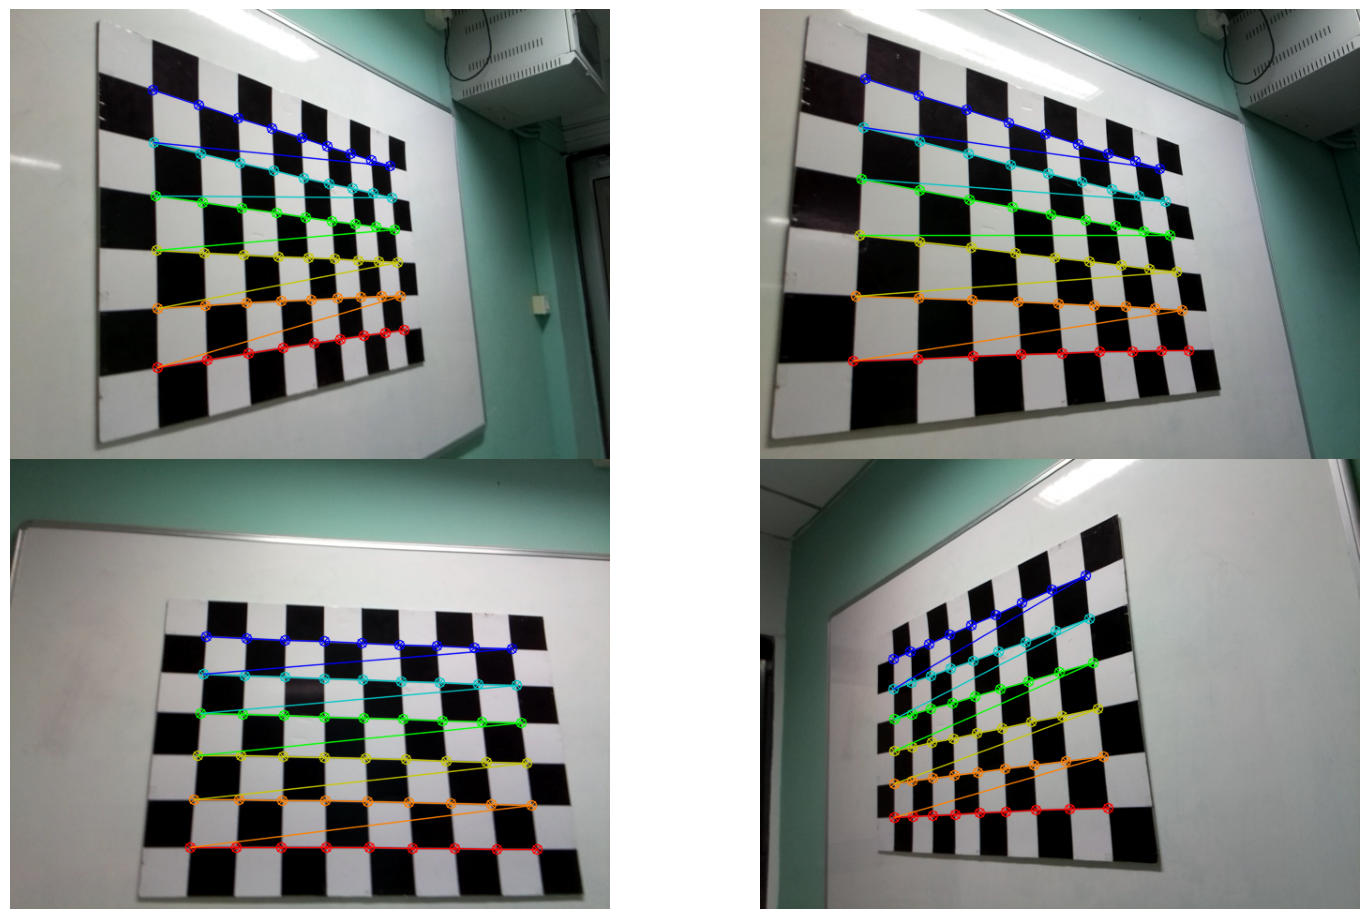

In [41]:
import numpy as np
import cv2 as cv
import glob

# termination criteria
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
objp = np.zeros((6*9,3), np.float32)
objp[:,:2] = np.mgrid[0:9,0:6].T.reshape(-1,2)

# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.

images = glob.glob(calibration_images_dir + "/" + "*.jpg")

rgb_images = []
for fname in images:
    img = cv.imread(fname)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Find the chess board corners
    ret, corners = cv.findChessboardCorners(gray, (9,6), None)

    # If found, add object points, image points (after refining them)
    if ret == True:
        objpoints.append(objp)

        corners2 = cv.cornerSubPix(gray,corners, (11,11), (-1,-1), criteria)
        imgpoints.append(corners2)

        # Draw and display the corners
        cv.drawChessboardCorners(img, (9,6), corners2, ret)

        # store rgb image
        color_fixed = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        rgb_images.append(color_fixed)


# Display a sample of images
image_grid(rgb_images[:4], rows=2, cols=2, rgb=True, show_axes=False)


# Calibrate camera
ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

### Undistort images using the lens-distortion coefficients

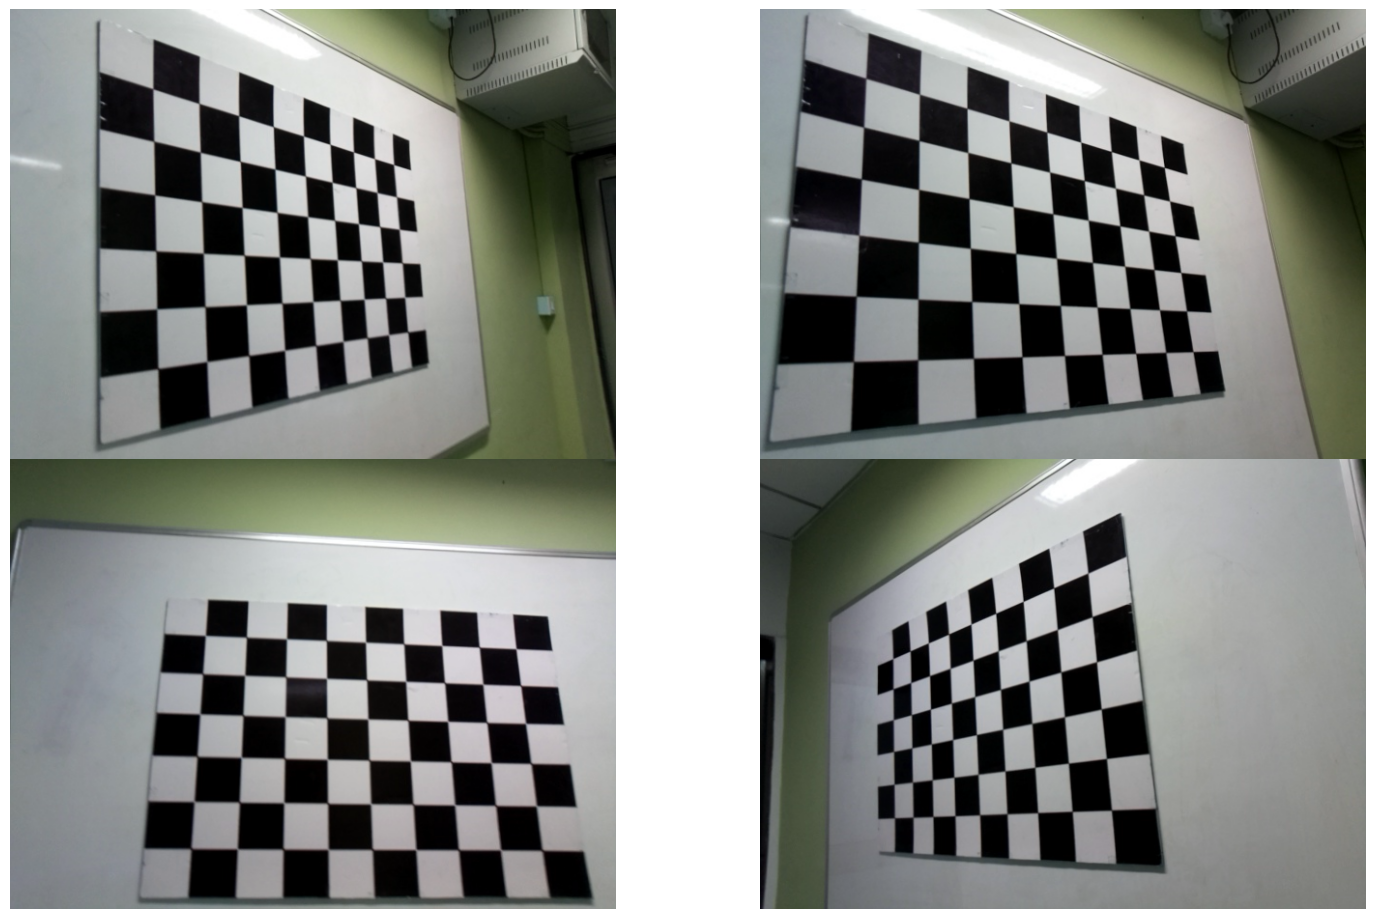

In [36]:
# Undistort all images
undistorted_images = []
for fname in images:
    img = cv.imread(fname)

    h,  w = img.shape[:2]
    newcameramtx, roi = cv.getOptimalNewCameraMatrix(mtx, dist, (w,h), 1, (w,h))

    # undistort
    dst = cv.undistort(img, mtx, dist, None, newcameramtx)

    # crop the image
    x, y, w, h = roi
    dst = dst[y:y+h, x:x+w]

    undistorted_images.append(dst)

# Display a sample of images
image_grid(undistorted_images[:4], rows=2, cols=2, rgb=True, show_axes=False)



## Estimating camera position for a set of images of a planar object

### Feature detection and matching

Here, we will use a set of four feature pairs corresponding to the corner of rectangles on the images.

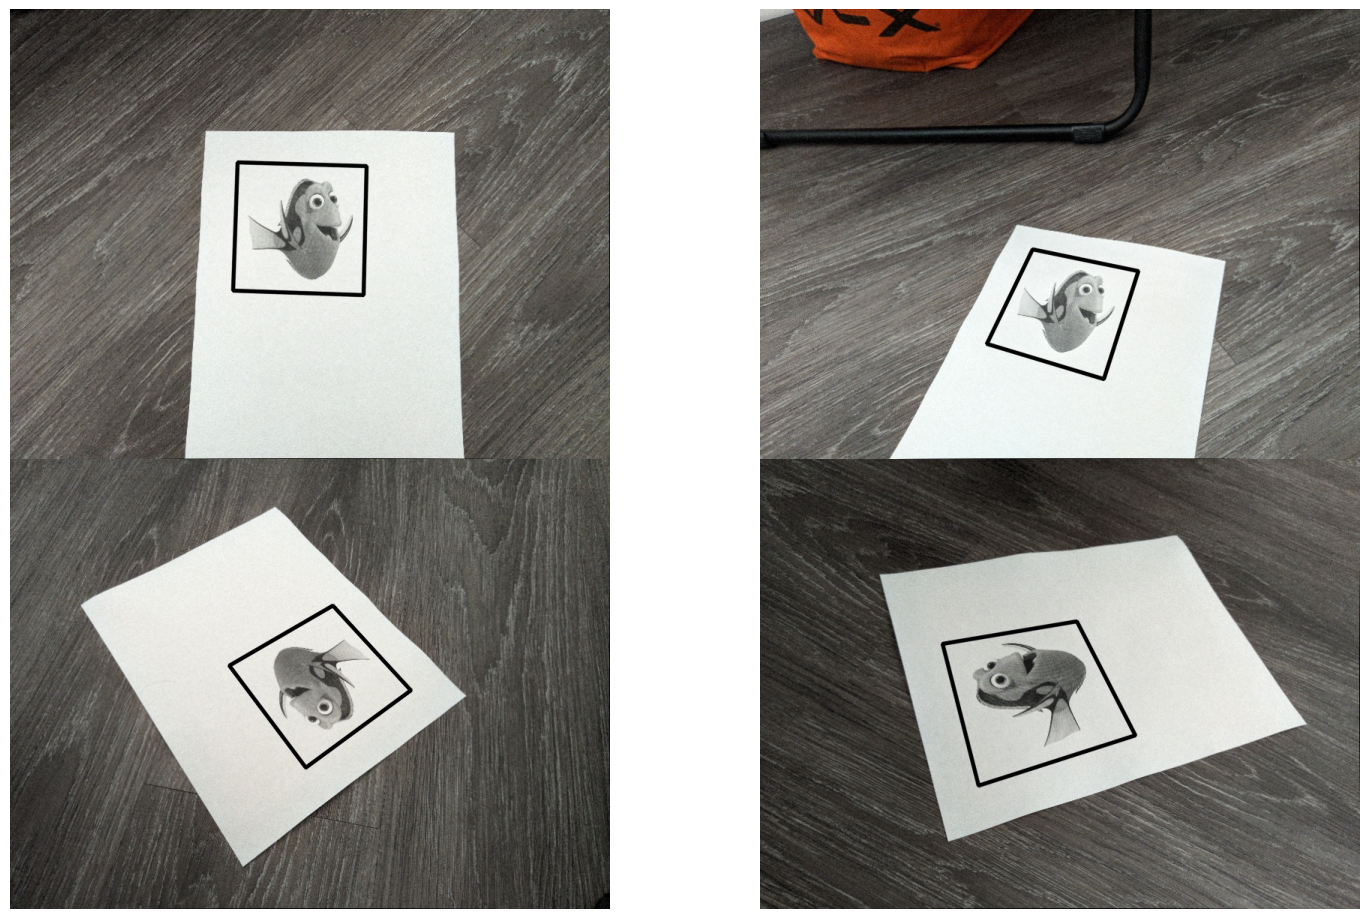

In [52]:
# Make a list of input images of the rectangles.
raw_images = [cv.imread(test_images_dir + "/" + 'dory_rectangle{}.jpg'.format(i)) for i in range(0, 4)]

# Convert all images in the list from BGR to RGB to show correct colors.
raw_images = [cv.cvtColor(img, cv.COLOR_BGR2RGB) for img in raw_images]

########################################################################
# In this example, the images are already scaled down and corrected
# for lens distortion. When using images from your own camera, you
# might need to scale them down and also correct for lens distortion.
# To do that, uncomment the following steps and adapt the names of variables.
########################################################################

# Undistort the images using the refined camera matrix (removes lens distortion)
#undistorted_images = [cv.undistort(img, camera_matrix, distortion_coefficients, None, refined_camera_matrix) for img in scaled_images]

# Display a sample of images
image_grid(raw_images, rows=2, cols=2, rgb=True, show_axes=False)


### Estimate homography transformation

Estimate the matrix $\Phi$ of the planar projective transformation.


#### Input data: reference points and image (feature) points
The input data for the homography calculation are a set of pairs of coordinates. Each pair is formed by a set of landmarks on the reference pattern and a set of correspoding feature points on the image of the reference pattern.

In [53]:
# Object points in world coordinates.
# The world coordinate frame and the object's coordinate frame are the same.
ref_points = [[[  0,   0]],
              [[  0, 511]],
              [[511, 511]],
              [[511,   0]]]

# Corresponding image points in the same order for all images
img_points =[
        [ # image 0
        [[305, 206]],
        [[298, 374]],
        [[471, 382]],
        [[476, 207]]
        ],
        [ # image 1
        [[363, 320]],
        [[302, 446]],
        [[458, 493]],
        [[504, 349]]
        ],
        [ # image 2
        [[534, 308]],
        [[431, 195]],
        [[292, 275]],
        [[394, 411]]
        ],
        [ # image 3
        [[291, 434]],
        [[500, 369]],
        [[423, 216]],
        [[243, 246]]
        ]
    ]

#### Show the labeled corners on the images

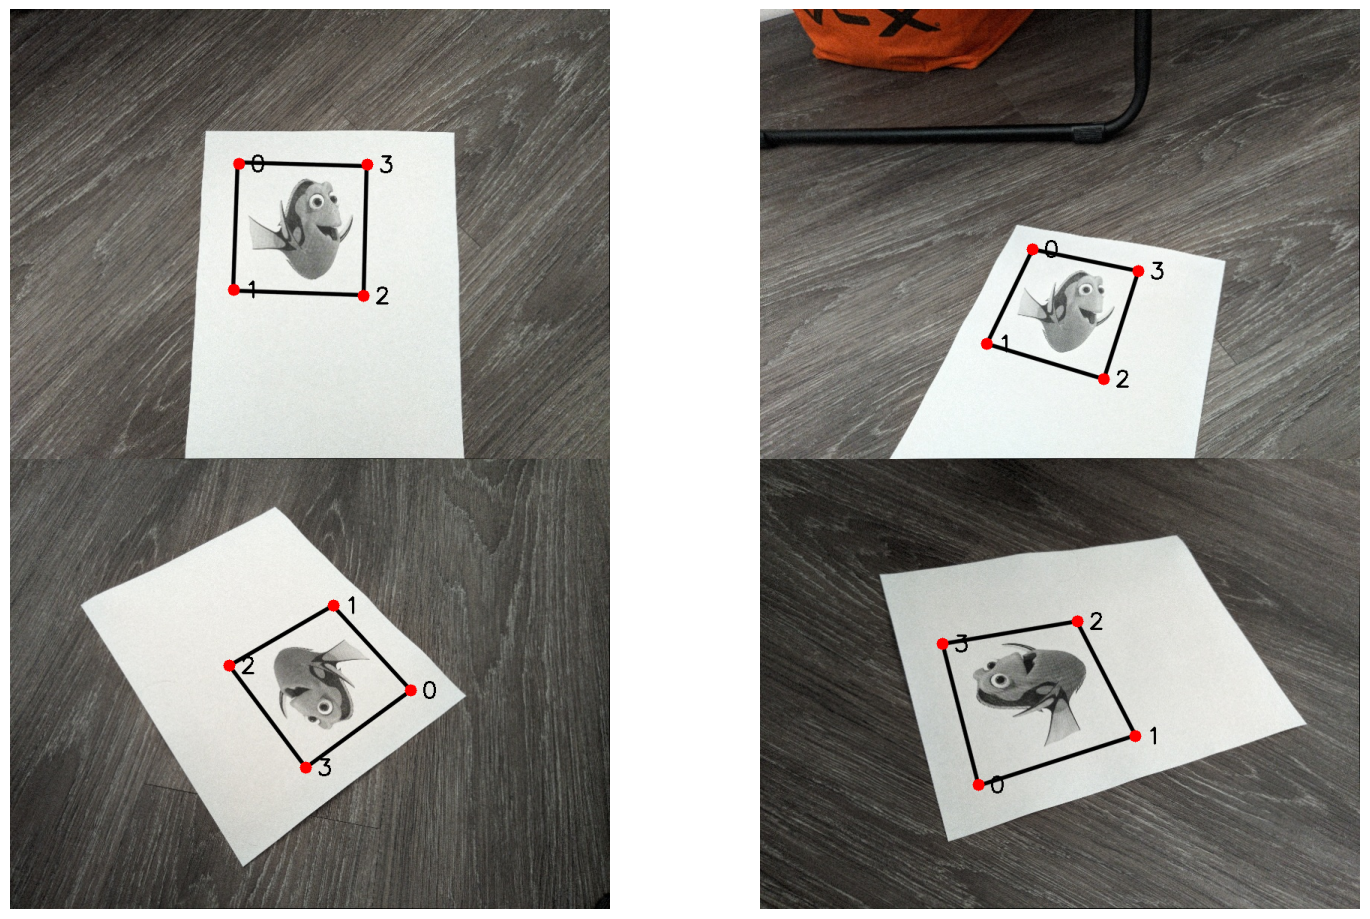

In [55]:
labelled_points = raw_images

for i in range(0,4):
    for j in range(0,4):
        # Draw circles at the image features
        labelled_points[i] = cv.circle(labelled_points[i],
                           (np.int32(img_points[i][j][0][0]),np.int32(img_points[i][j][0][1])),
                           8, (255,0,0), -1)

        # Draw text labels at the image features
        labelled_points[i] = cv.putText(labelled_points[i],'{}'.format(j),
                          (np.int32(img_points[i][j][0][0]+15),np.int32(img_points[i][j][0][1]+10)),
                          cv.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 2)

# Display a sample of images
image_grid(labelled_points, rows=2, cols=2, rgb=True, show_axes=False)


#### Find the homography matrix for each image

In [56]:
# Find the homography matrix for each image
#
# I'm using the built-in function instead of computing it myself because the built-in function
# filters out the outliers, which I wasn't able to get working well enough on my own
homography_matrices = []
matches_mask = []

printing.options['dformat'] = '%.3f'
printing.options['width'] = -1

for pts, idx in zip(img_points, range(0,4)):
    h, mask = cv.findHomography(np.array(ref_points), np.array(pts), cv.RANSAC, 5.0)

    print(f"H({idx}) = ")
    print(matrix(h))
    homography_matrices.append(h)
    matches_mask.append(mask.ravel().tolist())

H(0) = 
[  0.298  -0.021 305.000]
[ -0.014   0.319 206.000]
[ -0.000  -0.000   1.000]

H(1) = 
[  0.192  -0.191 363.000]
[ -0.002   0.141 320.000]
[ -0.000  -0.000   1.000]

H(2) = 
[ -0.363  -0.124 534.000]
[  0.109  -0.186 308.000]
[ -0.000   0.000   1.000]

H(3) = 
[  0.020   0.587 291.000]
[ -0.253   0.004 434.000]
[  0.000   0.000   1.000]



#### Extract extrinsic parameters form the homography

Factorize the homography matrix to extract the camera rotation and translation. This is the camera pose.


In [57]:
def extractExtrinsicParametersFromHomography(Phi, Lambda_inverse):
    """
    extractExtrinsicParametersFromHomography factorizes the homograpgy transformation to extract the camera pose,
                                             i.e., rotation matrix and translation vector.

    Input arguments:
    ------------------
        Phi:    3x3 homography matrix
        Lambda: 3x3 intrinsics matrix

    return:
    -------
        Omega: 3x3 Rotation matrix,
        tau:   3x1 translation vector

    """

    homography = Phi
    inverse_intrinsic_camera_matrix = Lambda_inverse

    # # Use openCV to estimate the camera's position and orientation
    # _, rotation, translation, _ = cv.decomposeHomographyMat(
    #     homography, camera_matrix)

    # # Add the rotation matrix and translation vector to the list of camera poses
    # camera_rotations.append(rotation)
    # camera_translations.append(translation)

    # Multiply the homography matrix by the inverse intrinsic camera matrix to eliminiate the effect
    # of the camera's intrinsic parameters
    homography_extrinsic = np.dot(inverse_intrinsic_camera_matrix, homography)

    # Estimate the first two columns of the rotation matrix by computing the SVD of the first two
    # columns of the homography matrix
    U, L, Vt = np.linalg.svd(homography_extrinsic[:, 0:2])
    new_L = np.array([[1, 0], [0, 1], [0, 0]])
    rotation_matrix = U @ new_L @ Vt

    # Estimate the third column of the rotation matrix by taking the cross product of the first two
    # columns
    third_column = np.cross(rotation_matrix[:, 0], rotation_matrix[:, 1])


    rotation_matrix = np.c_[rotation_matrix, third_column]

    # Verify that the rotation matrix is positive by checking its determinant
    if np.linalg.det(rotation_matrix) < 0:
        rotation_matrix[:, 2] *= -1

    # Estimate the scaling factor by taking the average of the scaling factors between the original
    # extrinsic homography matrix and the first two columns of the rotation matrix
    scaling_factor = np.sum(homography_extrinsic[:, 0:2] / rotation_matrix[:, 0:2]) / 6

    # Estimate the translation vector by dividing the third column of the extrinsic homography
    # matrix by the scaling factor
    translation = homography_extrinsic[:, 2] / scaling_factor

    # Rotation and translatioin
    Omega = rotation_matrix
    tau = translation

    return Omega, tau


In [59]:
# Calculate the inverse of the intrinsic camera matrix
inverse_intrinsic_camera_matrix = np.linalg.inv(mtx)

camera_rotations = []
camera_translations = []
for homography in homography_matrices:
    # Extract extrinsic parameters from homography
    rotation_matrix, translation = extractExtrinsicParametersFromHomography(homography, inverse_intrinsic_camera_matrix)

    # Add the rotation matrix and translation vector to the list of camera poses
    camera_rotations.append(rotation_matrix)
    camera_translations.append(translation)

# Reference frame
camera_rotations.append(np.eye(3))
camera_translations.append(np.array([0, 0, 0]))


# Print the camera poses
for i, (rotation, translation) in enumerate(zip(camera_rotations, camera_translations)):
    print("--------------------------------------")
    print("Camera pose {}:".format(i))
    print("--------------------------------------\n")
    print("Rotation:")
    print(matrix(rotation))
    print("Translation:")
    print(matrix(translation))


--------------------------------------
Camera pose 0:
--------------------------------------

Rotation:
[ 0.992 -0.030  0.119]
[ 0.025  0.999  0.043]
[-0.120 -0.040  0.992]

Translation:
[ -26.330]
[-116.160]
[1575.722]

--------------------------------------
Camera pose 1:
--------------------------------------

Rotation:
[ 0.908 -0.379  0.180]
[ 0.212  0.784  0.583]
[-0.362 -0.491  0.792]

Translation:
[ 199.660]
[ 309.899]
[2027.393]

--------------------------------------
Camera pose 2:
--------------------------------------

Rotation:
[-0.815 -0.571 -0.104]
[ 0.479 -0.763  0.434]
[-0.327  0.303  0.895]

Translation:
[ 674.221]
[ 198.538]
[1538.980]

--------------------------------------
Camera pose 3:
--------------------------------------

Rotation:
[-0.305  0.931 -0.199]
[-0.804 -0.141  0.577]
[ 0.510  0.336  0.792]

Translation:
[ -45.374]
[ 386.755]
[1019.305]

--------------------------------------
Camera pose 4:
--------------------------------------

Rotation:
[1.000 0.000

#### Draw the cameras (change coordinate frames)
To draw the cameras, we need to keep in mind that the camera-pose matrices that have been estimated from the homography transformations are written in terms of camera coordinate frames. As a result, we cannot use those matrices directly to plot the cameras. If we do, the cameras will not display properly. Instead, we need to calculate the inverse of the camera-pose matrices to obtain the camera pose written with respect to global coordinates.

The camera pose is represented by a rigid-body transformation, i.e.:

$$
\begin{align}
    T =
    \begin{bmatrix}
        \Omega & \tau \\
        {\bf 0} & 1
    \end{bmatrix},
\end{align}
$$

which has the following inverse:

$$
\begin{align}
    T^{-1} =
    \begin{bmatrix}
        \Omega^\mathsf{T} & -\Omega^\mathsf{T}\tau \\
        {\bf 0} & 1
    \end{bmatrix}.
\end{align}
$$